# Vintage batch processing for `2.output_images_random`

This notebook works independently from the export notebooks.

It:

1. reads every supported image in `2.output_images_random`;
2. lets you test a **random image with a random tint**;
3. shows the original and processed result side by side;
4. saves test previews separately;
5. optionally processes the entire folder into a new folder;
6. never modifies the source images.

Vintage treatment:

- saturation set to zero;
- warm highlight/base color `#FAF8F4`;
- random shadow tint selected from:
  - `#7A8A6A`
  - `#263020`
  - `#EAC0C0`
- `grain.jpg` superimposed at opacity `0.10`;
- output saved as high-quality JPEG.


In [18]:
# Install Pillow once if necessary:
# %pip install pillow

from pathlib import Path
import random

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageEnhance, ImageOps


In [19]:
# ==========================================================
# PATHS AND SETTINGS
# ==========================================================

SOURCE_FOLDER = Path(r"2.output_images_random")
GRAIN_PATH = Path(r"grain.jpg")

TEST_OUTPUT_FOLDER = Path(r"vintage_test_previews")
BATCH_OUTPUT_FOLDER = Path(r"3.output_images_vintage")

REPORT_PATH = BATCH_OUTPUT_FOLDER / "vintage_processing_report.csv"

SUPPORTED_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".webp",
    ".tif",
    ".tiff",
    ".bmp",
}

BASE_COLOR = "#FAF8F4"

TINT_COLORS = [
    "#7A8A6A",
    "#263020",
    "#E29B9B",
]

GRAIN_OPACITY = 0.30

# Extra controls
CONTRAST = 3.5
BRIGHTNESS = .6

# JPEG output settings
JPEG_QUALITY = 200

# False prevents overwriting existing outputs.
OVERWRITE = False

# Change this to obtain a different reproducible sequence.
RANDOM_SEED = 42

print("Source:", SOURCE_FOLDER)
print("Grain:", GRAIN_PATH)
print("Test previews:", TEST_OUTPUT_FOLDER)
print("Batch output:", BATCH_OUTPUT_FOLDER)


Source: 2.output_images_random
Grain: grain.jpg
Test previews: vintage_test_previews
Batch output: 3.output_images_vintage


In [20]:
# ==========================================================
# INITIAL VALIDATION
# ==========================================================

if not SOURCE_FOLDER.is_dir():
    raise NotADirectoryError(
        f"Source folder not found: {SOURCE_FOLDER}"
    )

if not GRAIN_PATH.is_file():
    raise FileNotFoundError(
        f"Grain image not found: {GRAIN_PATH}"
    )

TEST_OUTPUT_FOLDER.mkdir(parents=True, exist_ok=True)
BATCH_OUTPUT_FOLDER.mkdir(parents=True, exist_ok=True)

source_images = sorted(
    (
        path
        for path in SOURCE_FOLDER.iterdir()
        if path.is_file()
        and path.suffix.lower() in SUPPORTED_EXTENSIONS
    ),
    key=lambda path: path.name.lower(),
)

if not source_images:
    raise FileNotFoundError(
        f"No supported images found in: {SOURCE_FOLDER}"
    )

print("Images found:", f"{len(source_images):,}")
display(
    pd.DataFrame({
        "file": [path.name for path in source_images[:30]],
        "size_kb": [
            round(path.stat().st_size / 1024, 1)
            for path in source_images[:30]
        ],
    })
)


Images found: 432


,file,size_kb
0,0092caaa-f4cc-4c17-8bc5-e20cbe059637.jpg,1606.6
1,018a4cb2-a88f-4740-92f0-7cc61a152e51.jpg,14360.8
2,025184ae-5f48-4929-b70b-116342403adb.jpg,1559.7
3,029729ca-8660-4a6b-83a0-d516f223595c.jpg,6088.0
4,029c2f6d-739c-42ec-a7b3-7b6849fae1f8.jpg,128.9
5,02bb044c-8347-4335-8e1d-5d2f3844ded8.jpg,834.1
6,02f71bb3-78c0-46ba-83e2-9a25cfca315f.jpg,506.9
7,036eb456-54ba-4155-9fec-99a26d9a8aaf.jpg,816.8
8,03d8a957-5cc3-4da8-a160-2b733143771a.jpg,8894.2
9,0441c72d-b24e-4551-bbde-790c50af85f6.jpg,3152.3


In [21]:
# ==========================================================
# IMAGE PROCESSING FUNCTIONS
# ==========================================================

def hex_to_rgb(hex_color):
    value = hex_color.lstrip("#")

    if len(value) != 6:
        raise ValueError(
            f"Expected a six-digit hex color, received: {hex_color}"
        )

    return tuple(
        int(value[index:index + 2], 16)
        for index in (0, 2, 4)
    )


def prepare_grain(grain_path, target_size):
    grain = Image.open(grain_path)
    grain = ImageOps.exif_transpose(grain).convert("L")

    # Crop/resize without stretching the grain pattern.
    grain = ImageOps.fit(
        grain,
        target_size,
        method=Image.Resampling.LANCZOS,
    )

    return Image.merge(
        "RGB",
        (grain, grain, grain),
    )


def apply_vintage_effect(
    image_path,
    grain_path,
    tint_color,
    base_color=BASE_COLOR,
    grain_opacity=GRAIN_OPACITY,
    contrast=CONTRAST,
    brightness=BRIGHTNESS,
):
    image = Image.open(image_path)
    image = ImageOps.exif_transpose(image).convert("RGB")

    # Saturation = 0.
    grayscale = ImageOps.grayscale(image)

    # Random duotone:
    # dark pixels -> tint color
    # bright pixels -> warm base color
    result = ImageOps.colorize(
        grayscale,
        black=hex_to_rgb(tint_color),
        white=hex_to_rgb(base_color),
    ).convert("RGB")

    if contrast != 1:
        result = ImageEnhance.Contrast(result).enhance(contrast)

    if brightness != 1:
        result = ImageEnhance.Brightness(result).enhance(brightness)

    grain = prepare_grain(
        grain_path,
        result.size,
    )

    result = Image.blend(
        result,
        grain,
        grain_opacity,
    )

    return result


## Random test

Run the next cell repeatedly to select a new random image and a new random tint.

The preview is saved in `vintage_test_previews`, but the source image is never changed.


Random source: 6d13cb61-22ce-4877-b5e0-0fe7273b5099.jpg
Random tint: #7A8A6A
Base color: #FAF8F4
Grain opacity: 0.3
Saved preview: vintage_test_previews/6d13cb61-22ce-4877-b5e0-0fe7273b5099__7A8A6A.jpg


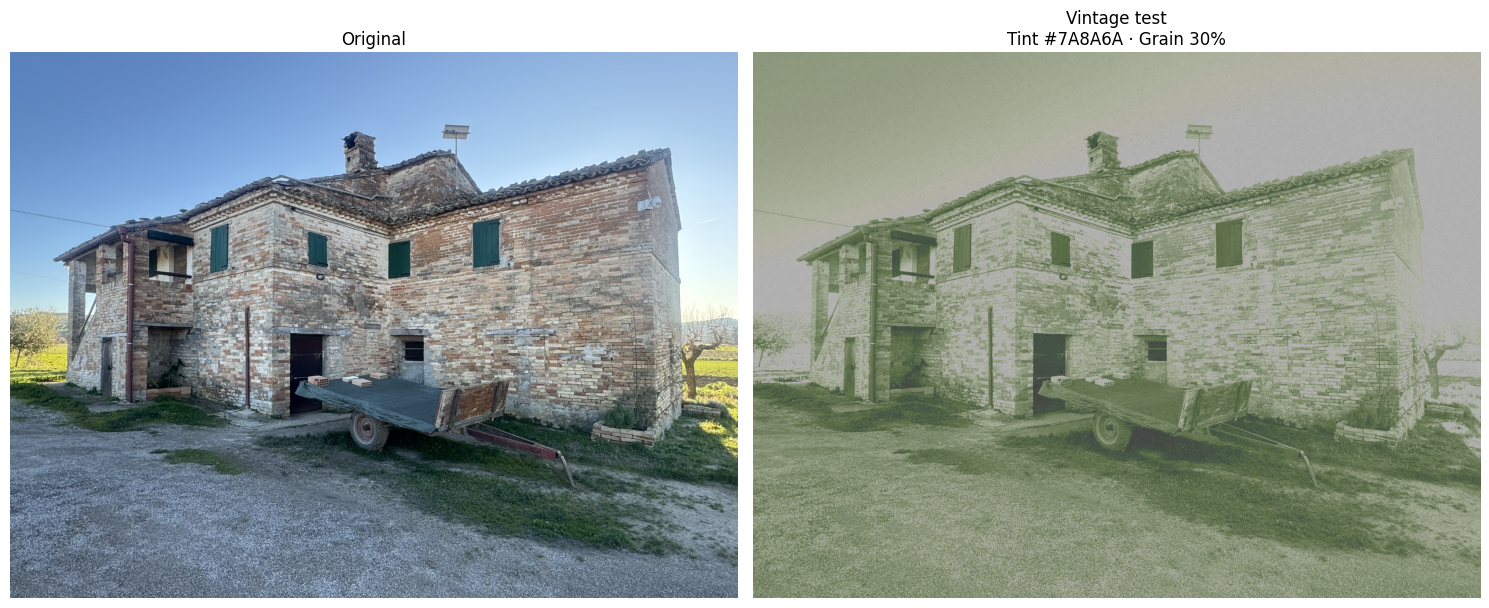

In [22]:
# ==========================================================
# RUN ONE RANDOM TEST
# ==========================================================

# SystemRandom gives a genuinely different choice on repeated runs.
test_rng = random.SystemRandom()

test_image_path = test_rng.choice(source_images)
test_tint = test_rng.choice(TINT_COLORS)

test_result = apply_vintage_effect(
    image_path=test_image_path,
    grain_path=GRAIN_PATH,
    tint_color=test_tint,
)

test_output_path = (
    TEST_OUTPUT_FOLDER
    / f"{test_image_path.stem}__{test_tint.lstrip('#')}.jpg"
)

test_result.save(
    test_output_path,
    format="JPEG",
    quality=JPEG_QUALITY,
    subsampling=0,
    optimize=True,
)

original = Image.open(test_image_path)
original = ImageOps.exif_transpose(original).convert("RGB")

print("Random source:", test_image_path.name)
print("Random tint:", test_tint)
print("Base color:", BASE_COLOR)
print("Grain opacity:", GRAIN_OPACITY)
print("Saved preview:", test_output_path)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 8),
)

axes[0].imshow(original)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(test_result)
axes[1].set_title(
    f"Vintage test\nTint {test_tint} · Grain {GRAIN_OPACITY:.0%}"
)
axes[1].axis("off")

plt.tight_layout()
plt.show()


## Compare all three tint options on one random image

This cell uses one random source image and shows the three possible treatments together.


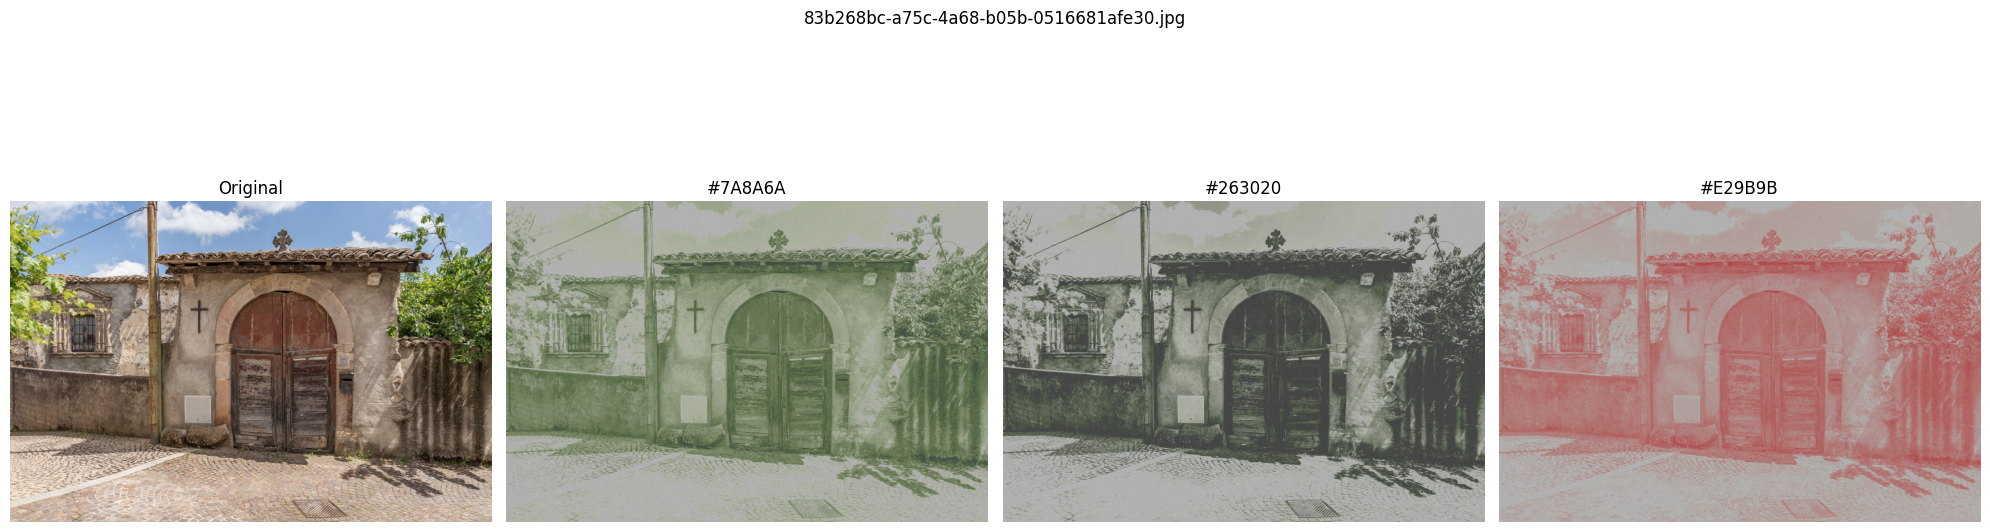

In [23]:
# ==========================================================
# COMPARE ALL TINTS ON ONE RANDOM IMAGE
# ==========================================================

comparison_rng = random.SystemRandom()
comparison_path = comparison_rng.choice(source_images)

comparison_original = Image.open(comparison_path)
comparison_original = ImageOps.exif_transpose(
    comparison_original
).convert("RGB")

comparison_results = [
    apply_vintage_effect(
        image_path=comparison_path,
        grain_path=GRAIN_PATH,
        tint_color=tint,
    )
    for tint in TINT_COLORS
]

fig, axes = plt.subplots(
    1,
    4,
    figsize=(20, 7),
)

axes[0].imshow(comparison_original)
axes[0].set_title("Original")
axes[0].axis("off")

for axis, tint, image in zip(
    axes[1:],
    TINT_COLORS,
    comparison_results,
):
    axis.imshow(image)
    axis.set_title(tint)
    axis.axis("off")

plt.suptitle(comparison_path.name)
plt.tight_layout()
plt.show()


## Batch processing

The next cell is disabled by default.

Set:

```python
RUN_BATCH = True
```

only after approving the preview. Every source image receives one randomly selected tint. The selection is reproducible using `RANDOM_SEED`.


In [24]:
# ==========================================================
# PROCESS THE ENTIRE FOLDER
# ==========================================================

RUN_BATCH = True

if RUN_BATCH:
    batch_rng = random.Random(RANDOM_SEED)
    rows = []

    for index, source_path in enumerate(source_images, start=1):
        tint = batch_rng.choice(TINT_COLORS)

        output_path = (
            BATCH_OUTPUT_FOLDER
            / f"{source_path.stem}.jpg"
        )

        record = {
            "source_name": source_path.name,
            "source_path": str(source_path),
            "output_name": output_path.name,
            "output_path": str(output_path),
            "base_color": BASE_COLOR,
            "tint_color": tint,
            "grain_opacity": GRAIN_OPACITY,
            "status": None,
        }

        try:
            if output_path.exists() and not OVERWRITE:
                record["status"] = "already_exists"
            else:
                result = apply_vintage_effect(
                    image_path=source_path,
                    grain_path=GRAIN_PATH,
                    tint_color=tint,
                )

                result.save(
                    output_path,
                    format="JPEG",
                    quality=JPEG_QUALITY,
                    subsampling=0,
                    optimize=True,
                )

                record["status"] = "exported"

        except Exception as error:
            record["status"] = (
                f"error: {type(error).__name__}: {error}"
            )

        rows.append(record)

        if index % 50 == 0 or index == len(source_images):
            print(
                f"Processed {index:,} / {len(source_images):,}"
            )

    report_df = pd.DataFrame(rows)

    report_df.to_csv(
        REPORT_PATH,
        index=False,
        encoding="utf-8-sig",
    )

    display(
        report_df["status"]
        .value_counts(dropna=False)
        .rename("count")
        .to_frame()
    )

    display(report_df.head())

    print("Output folder:", BATCH_OUTPUT_FOLDER)
    print("Report:", REPORT_PATH)

else:
    print(
        "Batch is disabled. Run the random test first, "
        "then set RUN_BATCH = True."
    )


Processed 50 / 432
Processed 100 / 432
Processed 150 / 432
Processed 200 / 432
Processed 250 / 432
Processed 300 / 432
Processed 350 / 432
Processed 400 / 432
Processed 432 / 432


,count
status,
exported,432


,source_name,source_path,output_name,output_path,base_color,tint_color,grain_opacity,status
0,0092caaa-f4cc-4c17-8bc5-e20cbe059637.jpg,2.output_images_random/0092caaa-f4cc-4c17-8bc5...,0092caaa-f4cc-4c17-8bc5-e20cbe059637.jpg,3.output_images_vintage/0092caaa-f4cc-4c17-8bc...,#FAF8F4,#E29B9B,0.3,exported
1,018a4cb2-a88f-4740-92f0-7cc61a152e51.jpg,2.output_images_random/018a4cb2-a88f-4740-92f0...,018a4cb2-a88f-4740-92f0-7cc61a152e51.jpg,3.output_images_vintage/018a4cb2-a88f-4740-92f...,#FAF8F4,#7A8A6A,0.3,exported
2,025184ae-5f48-4929-b70b-116342403adb.jpg,2.output_images_random/025184ae-5f48-4929-b70b...,025184ae-5f48-4929-b70b-116342403adb.jpg,3.output_images_vintage/025184ae-5f48-4929-b70...,#FAF8F4,#7A8A6A,0.3,exported
3,029729ca-8660-4a6b-83a0-d516f223595c.jpg,2.output_images_random/029729ca-8660-4a6b-83a0...,029729ca-8660-4a6b-83a0-d516f223595c.jpg,3.output_images_vintage/029729ca-8660-4a6b-83a...,#FAF8F4,#E29B9B,0.3,exported
4,029c2f6d-739c-42ec-a7b3-7b6849fae1f8.jpg,2.output_images_random/029c2f6d-739c-42ec-a7b3...,029c2f6d-739c-42ec-a7b3-7b6849fae1f8.jpg,3.output_images_vintage/029c2f6d-739c-42ec-a7b...,#FAF8F4,#263020,0.3,exported


Output folder: 3.output_images_vintage
Report: 3.output_images_vintage/vintage_processing_report.csv
